# DeiT Distilled Image Classification with OpenVINO™

Data-efficient Image Transformers (DeiT) are vision transformers trained entirely on ImageNet-1k (no extra data) using knowledge distillation. The **distilled DeiT-Tiny** variant achieves **74.5% Top-1** and **91.9% Top-5** accuracy.
This notebook demonstrates:

1. Loading a DeiT model from Hugging Face in **FP32** (PyTorch native precision).
2. Converting to OpenVINO IR in **FP16**.
3. Quantizing to **INT8** using NNCF accuracy-aware PTQ (≤ 1 % accuracy drop guaranteed).
4. Evaluating and comparing **FP32 PyTorch vs FP16 IR vs INT8 IR** on a 200-image ImageNet-1k subset.
5. Benchmarking latency and throughput.

#### Table of contents:
- [Prerequisites](#Prerequisites)
- [Select Model Variant](#Select-Model-Variant)
- [Load PyTorch Model (FP32)](#Load-PyTorch-Model)
- [Convert to OpenVINO FP16 IR](#Convert-to-OpenVINO-FP16-IR)
- [Compile and Run Single-Image Inference](#Compile-and-Run-Single-Image-Inference)
- [NNCF INT8 Quantization with Accuracy Control](#NNCF-INT8-Quantization)
- [Compare FP16 and INT8 Inference](#Compare-FP16-and-INT8-Inference)
- [Accuracy Evaluation — FP32 vs FP16 vs INT8](#Accuracy-Evaluation)
- [Benchmark with benchmark_app](#Benchmark)
- [Summary](#Summary)

### Installation Instructions
This notebook requires the `venv` kernel which includes `openvino`, `nncf`, `transformers`, `torch`, and `torchvision`.
Run all cells top-to-bottom; caching ensures converted/quantized models are reused on subsequent runs.

## Prerequisites
[back to top ⬆️](#Table-of-contents:)

Install required packages if not already present.

In [3]:
%pip install -q "openvino>=2025.1.0" "nncf>=2.16.0" transformers torchvision datasets pillow matplotlib --quiet


Note: you may need to restart the kernel to use updated packages.


## Select Model Variant
[back to top ⬆️](#Table-of-contents:)

DeiT-Tiny, Small, and Base are all trained on ImageNet-1k with the same data-efficient distillation recipe.  
Use the dropdown to select which variant to convert and evaluate.

| Variant | HF model id | Params | Published top-1 |
| --- | --- | ---: | ---: |
| DeiT-Tiny Dist.  | `facebook/deit-tiny-distilled-patch16-224`  | 6 M  | **74.5 %** |
| DeiT-Small Dist. | `facebook/deit-small-distilled-patch16-224` | 22 M | 81.2 % |
| DeiT-Base Dist.  | `facebook/deit-base-distilled-patch16-224`  | 87 M | 83.4 % |

In [4]:
import ipywidgets as widgets

MODEL_OPTIONS = {
    "DeiT-Tiny Dist. (6 M)" : "facebook/deit-tiny-distilled-patch16-224",
    "DeiT-Small Dist. (22 M)": "facebook/deit-small-distilled-patch16-224",
    "DeiT-Base Dist. (86 M)" : "facebook/deit-base-distilled-patch16-224",
}

model_dropdown = widgets.Dropdown(
    options=list(MODEL_OPTIONS.keys()),
    value="DeiT-Tiny Dist. (6 M)",
    description="Model:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="360px"),
)
model_dropdown


Dropdown(description='Model:', layout=Layout(width='360px'), options=('DeiT-Tiny Dist. (6 M)', 'DeiT-Small Dis…

In [5]:
import os
from pathlib import Path
import time
import numpy as np

MODEL_ID   = MODEL_OPTIONS[model_dropdown.value]
MODEL_NAME = MODEL_ID.split("/")[-1].replace("-", "_")

REPO_ROOT   = Path.cwd()
if not (REPO_ROOT / "assets").exists() and (REPO_ROOT.parent / "assets").exists():
    REPO_ROOT = REPO_ROOT.parent

MODEL_DIR   = REPO_ROOT / "openvino_irs" / MODEL_NAME
OUTPUT_DIR  = REPO_ROOT / "outputs"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FP16_XML    = MODEL_DIR / f"openvino_{MODEL_NAME}_fp16.xml"
INT8_XML    = MODEL_DIR / f"openvino_{MODEL_NAME}_int8.xml"
DEVICE      = os.environ.get("DEVICE", "GPU")

TEST_IMAGE  = REPO_ROOT / "assets/test_images/getty_LeBron.jpg"
IMAGE_SIZE  = 224
TOP_K       = 5

print(f"Model        : {MODEL_ID}")
print(f"FP16 IR path : {FP16_XML}")
print(f"INT8 IR path : {INT8_XML}")
print(f"Device       : {DEVICE}")
print(f"Test image   : {TEST_IMAGE}")


Model        : facebook/deit-tiny-distilled-patch16-224
FP16 IR path : /home/tj/OPENVINO_NB_CHECKS/openvino_irs/deit_tiny_distilled_patch16_224/openvino_deit_tiny_distilled_patch16_224_fp16.xml
INT8 IR path : /home/tj/OPENVINO_NB_CHECKS/openvino_irs/deit_tiny_distilled_patch16_224/openvino_deit_tiny_distilled_patch16_224_int8.xml
Device       : GPU
Test image   : /home/tj/OPENVINO_NB_CHECKS/assets/test_images/getty_LeBron.jpg


## Load PyTorch Model (FP32)
[back to top ⬆️](#Table-of-contents:)

> **PyTorch native precision:** DeiT models are stored and loaded as **FP32** (`torch.float32`).  
> This is the reference for all accuracy comparisons in this notebook.

The thin `DeiTLogitsWrapper` exposes a single `pixel_values → logits` signature that OpenVINO's tracing path handles cleanly.

In [6]:
import torch
from transformers import AutoImageProcessor, AutoModelForImageClassification

processor = AutoImageProcessor.from_pretrained(MODEL_ID)
pt_model  = AutoModelForImageClassification.from_pretrained(MODEL_ID)
pt_model.eval()
for p in pt_model.parameters():
    p.requires_grad = False

# Confirm FP32
native_dtype  = next(pt_model.parameters()).dtype
total_params  = sum(p.numel() for p in pt_model.parameters()) / 1e6
print(f"PyTorch model dtype : {native_dtype}")
print(f"Parameters          : {total_params:.1f} M")
print(f"Number of classes   : {len(pt_model.config.id2label)}")

class DeiTLogitsWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, pixel_values):
        return self.model(pixel_values=pixel_values).logits

wrapped_model = DeiTLogitsWrapper(pt_model).eval()
dummy_input   = torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE)


Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

PyTorch model dtype : torch.float32
Parameters          : 5.9 M
Number of classes   : 1000


## Convert to OpenVINO FP16 IR
[back to top ⬆️](#Table-of-contents:)

The model is traced from its FP32 PyTorch form and saved as FP16 (`compress_to_fp16=True`).  
Conversion is cache-aware: re-running this cell skips if the XML already exists.

In [7]:
import openvino as ov

if not FP16_XML.exists():
    with torch.no_grad():
        ov_fp16 = ov.convert_model(
            wrapped_model,
            example_input=dummy_input,
            input=[(1, 3, IMAGE_SIZE, IMAGE_SIZE)],
        )
    ov.save_model(ov_fp16, FP16_XML, compress_to_fp16=True)
    print(f"Saved FP16 IR  → {FP16_XML}")
else:
    print(f"Reusing FP16 IR : {FP16_XML}")

print(f"BIN size         : {FP16_XML.with_suffix('.bin').stat().st_size / 1e6:.1f} MB")


Reusing FP16 IR : /home/tj/OPENVINO_NB_CHECKS/openvino_irs/deit_tiny_distilled_patch16_224/openvino_deit_tiny_distilled_patch16_224_fp16.xml
BIN size         : 11.8 MB


## Compile and Run Single-Image Inference
[back to top ⬆️](#Table-of-contents:)

Both FP16 and (once created) INT8 IRs are compiled on the selected device. The section below uses the FP16 model for the demo inference.

Compiling FP16 IR on GPU...
  input  pixel_values         [1,3,224,224]
  output out_0                [1,1000]
✓ FP16 compiled


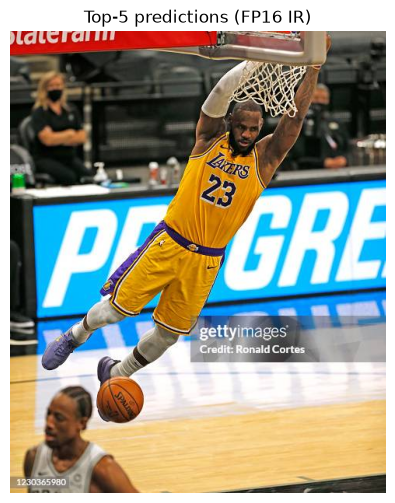


FP16 IR top-5 predictions:
  1. basketball                               0.9962
  2. volleyball                               0.0011
  3. balance beam, beam                       0.0004
  4. unicycle, monocycle                      0.0002
  5. racket, racquet                          0.0001


In [8]:
from PIL import Image
import matplotlib.pyplot as plt

core = ov.Core()

def _load_and_compile(xml_path: Path, device: str):
    m = core.read_model(xml_path)
    # Handle unnamed outputs (common in traced models)
    def _port_name(port, fallback):
        names = port.get_names()
        return next(iter(names)) if names else fallback
    for i, inp in enumerate(m.inputs):
        print(f"  input  {_port_name(inp, f'in_{i}'):20s} {inp.get_partial_shape()}")
    for i, out in enumerate(m.outputs):
        print(f"  output {_port_name(out, f'out_{i}'):20s} {out.get_partial_shape()}")
    compiled = core.compile_model(m, device)
    return compiled

print(f"Compiling FP16 IR on {DEVICE}...")
fp16_model = _load_and_compile(FP16_XML, DEVICE)
fp16_input = fp16_model.input(0)
fp16_output = fp16_model.output(0)
print(f"✓ FP16 compiled")

# Single-image inference
if not TEST_IMAGE.exists():
    raise FileNotFoundError(f"Test image not found: {TEST_IMAGE}")

image = Image.open(TEST_IMAGE).convert("RGB")
pixel_values = processor(images=image, return_tensors="pt")["pixel_values"].numpy()

logits_fp16 = fp16_model({fp16_input: pixel_values})[fp16_output]
probs = np.exp(logits_fp16 - logits_fp16.max(axis=-1, keepdims=True))
probs = probs / probs.sum(axis=-1, keepdims=True)
top_idx = np.argsort(probs[0])[-TOP_K:][::-1]

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title(f"Top-{TOP_K} predictions (FP16 IR)")
plt.show()

print(f"\nFP16 IR top-{TOP_K} predictions:")
for rank, idx in enumerate(top_idx, 1):
    print(f"  {rank}. {pt_model.config.id2label[int(idx)]:40s} {probs[0, idx]:.4f}")


## NNCF INT8 Quantization with Accuracy Control
[back to top ⬆️](#Table-of-contents:)

[NNCF](https://github.com/openvinotoolkit/nncf) post-training quantization with `nncf.quantize_with_accuracy_control` guarantees the INT8 model stays **within 1 % top-1 accuracy** of the FP16 IR reference.  

Key parameters:
- `max_drop = 0.01` — hard cap on allowed accuracy drop.
- `drop_type = DropType.ABSOLUTE` — interpreted as absolute percentage points.
- `ranking_subset_size = 50` — number of samples used for per-layer sensitivity ranking (controls speed vs. quality).
- Calibration dataset: 200 streamed images from `evanarlian/imagenet_1k_resized_256`.

In [9]:
# ── Calibration / validation dataset ──────────────────────────────────────
from pathlib import Path as _Path
from torchvision import transforms as T

HF_STREAM_DATASET = "evanarlian/imagenet_1k_resized_256"
HF_STREAM_SPLIT   = "val"
N_CALIB           = int(os.environ.get("NNCF_CALIB_SAMPLES", "300"))
N_VAL             = int(os.environ.get("NNCF_VAL_SAMPLES",   "300"))
RANKING_SUBSET    = int(os.environ.get("NNCF_RANKING_SUBSET", "50"))
MAX_ACCURACY_DROP = float(os.environ.get("MAX_ACCURACY_DROP",  "0.01"))  # 1 %
SAMPLE_STEP       = 165   # 50 000 / 165 ≈ 300 samples per phase

# Standard DeiT eval pre-processing (images already shorter-side 256)
_eval_tf = T.Compose([
    T.CenterCrop(IMAGE_SIZE),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

def _preprocess(img: Image.Image) -> np.ndarray:
    return _eval_tf(img).unsqueeze(0).numpy()

hf_token_path = _Path.home() / ".cache/huggingface/token"
hf_token = hf_token_path.read_text().strip() if hf_token_path.exists() else None

def _stream_imagenet(n: int, phase_offset: int = 0) -> list:
    """
    Return n samples by taking every SAMPLE_STEP-th image starting at phase_offset.
    phase_offset 0   → indices 0, 250, 500 ...  (classes 0, 5, 10 ...)
    phase_offset 125 → indices 125, 375, 625 ... (classes 2, 7, 12 ...)
    The two phases are non-overlapping and together cover all 1000 classes.
    """
    from datasets import load_dataset
    ds = load_dataset(HF_STREAM_DATASET, split=HF_STREAM_SPLIT, streaming=True, token=hf_token)
    samples = []
    for i, sample in enumerate(ds):
        if i < phase_offset:
            continue
        if (i - phase_offset) % SAMPLE_STEP == 0:
            pv = _preprocess(sample["image"].convert("RGB"))
            samples.append((pv, int(sample["label"])))
        if len(samples) >= n:
            break
    return samples

# ── Stream calibration and validation images ───────────────────────────────
# Dataset: evanarlian/imagenet_1k_resized_256 (publicly accessible on HF Hub)
# If streaming fails due to connectivity or missing packages, a download link
# is provided below.
try:
    print(f"Preparing {N_CALIB} calibration samples  (phase 0, every {SAMPLE_STEP}th) …")
    calib_data = _stream_imagenet(N_CALIB, phase_offset=0)
    print(f"  → {len(calib_data)} calibration images ready")

    print(f"Preparing {N_VAL} validation samples (phase 125, every {SAMPLE_STEP}th) …")
    val_data   = _stream_imagenet(N_VAL, phase_offset=125)
    print(f"  → {len(val_data)} validation images ready")

except Exception as _e:
    calib_data = []
    val_data   = []
    print()
    print("=" * 70)
    print("  DATASET NOT AVAILABLE")
    print("=" * 70)
    print(f"  Error: {_e}")
    print()
    print("  The notebook streams from Hugging Face:")
    print(f"    {HF_STREAM_DATASET}")
    print()
    print("  To fix, choose one of the options below:")
    print()
    print("  Option A — Install the datasets package and run again:")
    print("    pip install datasets")
    print()
    print("  Option B — Log in to Hugging Face (needed for some environments):")
    print("    huggingface-cli login")
    print("    # Then re-run this cell")
    print()
    print("  Option C — Download a local copy of ImageNet-1k resized to 256 px:")
    print("    Dataset page : https://huggingface.co/datasets/evanarlian/imagenet_1k_resized_256")
    print("    Direct clone : huggingface-cli download evanarlian/imagenet_1k_resized_256")
    print()
    print("  Option D — Use the original ImageNet-1k validation set (6.3 GB):")
    print("    Registration : https://image-net.org/download.php")
    print("    Arrange as   : val/<synset_id>/*.JPEG  then set EVAL_DATA_DIR env var.")
    print()
    print("  After obtaining data, re-run this cell before running the NNCF cell.")
    print("=" * 70)

Preparing 300 calibration samples  (phase 0, every 165th) …


README.md:   0%|          | 0.00/42.8k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/52 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/52 [00:00<?, ?it/s]

  → 300 calibration images ready
Preparing 300 validation samples (phase 125, every 165th) …


Resolving data files:   0%|          | 0/52 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/52 [00:00<?, ?it/s]

  → 300 validation images ready


In [10]:
import nncf
from nncf.quantization.advanced_parameters import AdvancedAccuracyRestorerParameters
from nncf import DropType

# ── NNCF Dataset wrappers ──────────────────────────────────────────────────
# Calibration: input tensors only (pixel value numpy arrays)
nncf_calib_dataset = nncf.Dataset([pv for pv, _ in calib_data])

# Precomputed labels aligned to the validation pixel-value list
_val_labels = [lbl for _, lbl in val_data]
_val_pvs    = [pv  for pv, _ in val_data]

# NNCF accuracy-control calls validation_fn(model, data_iter) where
# data_iter yields the raw items from the Dataset passed as validation_dataset.
def _validate_fn(model: ov.CompiledModel, data) -> float:
    inp    = model.input(0)
    outp   = model.output(0)
    correct = 0
    for idx, pv in enumerate(data):
        logits  = model({inp: pv})[outp]
        pred    = int(np.argmax(logits[0]))
        correct += int(pred == _val_labels[idx])
    total = idx + 1 if idx >= 0 else 0  # type: ignore[possibly-undefined]
    return correct / total if total else 0.0

# ── Run quantization (cache-aware) ────────────────────────────────────────
if INT8_XML.exists():
    print(f"Reusing INT8 IR : {INT8_XML}")
else:
    print(f"Starting accuracy-aware INT8 quantization ...")
    print(f"  max_drop={MAX_ACCURACY_DROP*100:.1f}%  calib={N_CALIB}  val={N_VAL}  ranking_subset={RANKING_SUBSET}")

    fp16_ov_model = core.read_model(FP16_XML)

    int8_model = nncf.quantize_with_accuracy_control(
        fp16_ov_model,
        calibration_dataset=nncf_calib_dataset,
        validation_dataset=nncf.Dataset(_val_pvs),
        validation_fn=_validate_fn,
        max_drop=MAX_ACCURACY_DROP,
        drop_type=DropType.ABSOLUTE,
        advanced_accuracy_restorer_parameters=AdvancedAccuracyRestorerParameters(
            ranking_subset_size=RANKING_SUBSET,
            max_num_iterations=50,
        ),
    )

    ov.save_model(int8_model, INT8_XML)
    print(f"\nSaved INT8 IR → {INT8_XML}")
    print(f"BIN size      : {INT8_XML.with_suffix('.bin').stat().st_size / 1e6:.1f} MB")

print("\nINT8 IR ready.")


Reusing INT8 IR : /home/tj/OPENVINO_NB_CHECKS/openvino_irs/deit_tiny_distilled_patch16_224/openvino_deit_tiny_distilled_patch16_224_int8.xml

INT8 IR ready.


## Compare FP16 and INT8 Inference
[back to top ⬆️](#Table-of-contents:)

Compile the INT8 model and run it on the same test image to confirm the top-1 prediction is consistent.

In [11]:
print(f"Compiling INT8 IR on {DEVICE}...")
int8_model = _load_and_compile(INT8_XML, DEVICE)
int8_input  = int8_model.input(0)
int8_output = int8_model.output(0)
print("✓ INT8 compiled")

# Run on the same test image
logits_int8 = int8_model({int8_input: pixel_values})[int8_output]

with torch.no_grad():
    logits_fp32 = pt_model(pixel_values=torch.from_numpy(pixel_values)).logits.numpy()

fp32_top1  = pt_model.config.id2label[int(logits_fp32[0].argmax())]
fp16_top1  = pt_model.config.id2label[int(logits_fp16[0].argmax())]
int8_top1  = pt_model.config.id2label[int(logits_int8[0].argmax())]

print(f"\nSingle-image top-1 comparison on {TEST_IMAGE.name}:")
print(f"  PyTorch FP32 : {fp32_top1}")
print(f"  OpenVINO FP16: {fp16_top1}")
print(f"  OpenVINO INT8: {int8_top1}")
print(f"\nMax |FP32 - FP16| logits diff : {np.abs(logits_fp32 - logits_fp16).max():.5f}")
print(f"Max |FP32 - INT8| logits diff : {np.abs(logits_fp32 - logits_int8).max():.5f}")


Compiling INT8 IR on GPU...
  input  pixel_values         [1,3,224,224]
  output out_0                [1,1000]
✓ INT8 compiled

Single-image top-1 comparison on getty_LeBron.jpg:
  PyTorch FP32 : basketball
  OpenVINO FP16: basketball
  OpenVINO INT8: basketball

Max |FP32 - FP16| logits diff : 0.01160
Max |FP32 - INT8| logits diff : 3.34787


## Accuracy Evaluation — FP32 vs FP16 vs INT8
[back to top ⬆️](#Table-of-contents:)

All three runtimes are evaluated on the same 200-image ImageNet-1k validation subset (reusing `val_data` prepared earlier).  
The baseline is the **PyTorch FP32** model. Published reference: DeiT-Tiny Dist. → **74.5 % Top-1 / 91.9 % Top-5**.  
The NNCF accuracy-control quantization guarantees the INT8 top-1 is within **1 %** of the FP16 IR baseline.

In [12]:
def _eval_pytorch(data):
    total = top1 = top5 = 0
    pt_model.eval()
    t0 = time.perf_counter()
    with torch.no_grad():
        for pv, label in data:
            logits = pt_model(pixel_values=torch.from_numpy(pv)).logits[0]
            pred5  = logits.topk(5).indices.tolist()
            total += 1
            top1  += int(pred5[0] == label)
            top5  += int(label in pred5)
    elapsed = time.perf_counter() - t0
    return {"top1": top1/total*100, "top5": top5/total*100,
            "img_per_s": total/elapsed, "samples": total}

def _eval_openvino(compiled, inp_port, out_port, data):
    total = top1 = top5 = 0
    t0 = time.perf_counter()
    for pv, label in data:
        logits = compiled({inp_port: pv})[out_port]
        pred5  = np.argsort(logits[0])[-5:][::-1].tolist()
        total += 1
        top1  += int(pred5[0] == label)
        top5  += int(label in pred5)
    elapsed = time.perf_counter() - t0
    return {"top1": top1/total*100, "top5": top5/total*100,
            "img_per_s": total/elapsed, "samples": total}

print(f"Evaluating on {len(val_data)} validation images ...\n")

print("[1/3] PyTorch FP32")
res_fp32 = _eval_pytorch(val_data)
print(f"      top-1 {res_fp32['top1']:.2f}%  top-5 {res_fp32['top5']:.2f}%  throughput {res_fp32['img_per_s']:.1f} img/s")

print("[2/3] OpenVINO FP16 IR")
res_fp16 = _eval_openvino(fp16_model, fp16_input, fp16_output, val_data)
print(f"      top-1 {res_fp16['top1']:.2f}%  top-5 {res_fp16['top5']:.2f}%  throughput {res_fp16['img_per_s']:.1f} img/s")

print("[3/3] OpenVINO INT8 IR")
res_int8 = _eval_openvino(int8_model, int8_input, int8_output, val_data)
print(f"      top-1 {res_int8['top1']:.2f}%  top-5 {res_int8['top5']:.2f}%  throughput {res_int8['img_per_s']:.1f} img/s")


Evaluating on 300 validation images ...

[1/3] PyTorch FP32
      top-1 76.67%  top-5 94.00%  throughput 154.2 img/s
[2/3] OpenVINO FP16 IR
      top-1 76.67%  top-5 94.00%  throughput 1364.0 img/s
[3/3] OpenVINO INT8 IR
      top-1 75.33%  top-5 94.00%  throughput 1445.4 img/s


## Benchmark with benchmark_app
[back to top ⬆️](#Table-of-contents:)

Use the OpenVINO `benchmark_app` CLI to measure steady-state latency and throughput for both IRs.

In [13]:
import re
import shutil
import subprocess

BENCH_SECONDS = int(os.environ.get("BENCHMARK_SECONDS", "30"))
benchmark_app = shutil.which("benchmark_app")
if benchmark_app is None:
    raise FileNotFoundError("benchmark_app not found on PATH")

def _run_benchmark(xml_path: Path, label: str) -> dict:
    cmd = [
        benchmark_app, "-m", str(xml_path),
        "-d", DEVICE,
        "-shape", f"[1,3,{IMAGE_SIZE},{IMAGE_SIZE}]",
        "-hint", "latency", "-api", "sync", "-t", str(BENCH_SECONDS),
    ]
    print(f"\n{'─'*60}")
    print(f"  {label}  ({BENCH_SECONDS}s, latency/sync, {DEVICE})")
    print(f"  {' '.join(cmd)}")
    proc = subprocess.run(cmd, check=True, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
    fps_m   = re.search(r"Throughput:\s*([0-9.]+)\s*FPS",  proc.stdout)
    lat_m   = re.search(r"Average:\s*([0-9.]+)\s*ms",       proc.stdout)
    fps     = float(fps_m.group(1)) if fps_m else None
    lat     = float(lat_m.group(1)) if lat_m else None
    print(f"  → Average latency: {lat} ms   Throughput: {fps} FPS")
    return {"fps": fps, "latency_ms": lat}

bench_fp16 = _run_benchmark(FP16_XML, f"FP16 IR ({MODEL_NAME})")
bench_int8 = _run_benchmark(INT8_XML, f"INT8 IR ({MODEL_NAME})")



────────────────────────────────────────────────────────────
  FP16 IR (deit_tiny_distilled_patch16_224)  (30s, latency/sync, GPU)
  /home/tj/frameworks.ai.benchmarking.archbenchmetricsuite/.venv/bin/benchmark_app -m /home/tj/OPENVINO_NB_CHECKS/openvino_irs/deit_tiny_distilled_patch16_224/openvino_deit_tiny_distilled_patch16_224_fp16.xml -d GPU -shape [1,3,224,224] -hint latency -api sync -t 30
  → Average latency: 0.56 ms   Throughput: 1751.62 FPS

────────────────────────────────────────────────────────────
  INT8 IR (deit_tiny_distilled_patch16_224)  (30s, latency/sync, GPU)
  /home/tj/frameworks.ai.benchmarking.archbenchmetricsuite/.venv/bin/benchmark_app -m /home/tj/OPENVINO_NB_CHECKS/openvino_irs/deit_tiny_distilled_patch16_224/openvino_deit_tiny_distilled_patch16_224_int8.xml -d GPU -shape [1,3,224,224] -hint latency -api sync -t 30
  → Average latency: 0.63 ms   Throughput: 1564.37 FPS


## Summary
[back to top ⬆️](#Table-of-contents:)

In [14]:
fp16_top1_delta = res_fp16['top1'] - res_fp32['top1']
fp16_top5_delta = res_fp16['top5'] - res_fp32['top5']
int8_top1_delta = res_int8['top1'] - res_fp32['top1']
int8_top5_delta = res_int8['top5'] - res_fp32['top5']
int8_speedup_acc = res_int8['img_per_s'] / res_fp32['img_per_s']
int8_speedup_bm  = bench_int8['fps'] / bench_fp16['fps'] if bench_int8['fps'] and bench_fp16['fps'] else None

lines = [
    f"Model selected : {MODEL_ID}",
    f"Eval images    : {len(val_data)} (ImageNet-1k validation subset)",
    f"Baseline       : PyTorch FP32 — {res_fp32['top1']:.2f}% top-1 / {res_fp32['top5']:.2f}% top-5",
    "",
    "### Accuracy",
    "",
    f"{'Runtime':<24} {'Precision':<10} {'Top-1':>8} {'Top-5':>8}  {'Δ Top-1':>9}  {'Δ Top-5':>9}",
    "─" * 82,
    f"{'PyTorch (CPU)':<24} {'FP32':<10} {res_fp32['top1']:>7.2f}% {res_fp32['top5']:>7.2f}%  {'—':>9}  {'—':>9}",
    f"{'OpenVINO IR':<24} {'FP16':<10} {res_fp16['top1']:>7.2f}% {res_fp16['top5']:>7.2f}%  {fp16_top1_delta:>+8.2f}%  {fp16_top5_delta:>+8.2f}%",
    f"{'OpenVINO IR':<24} {'INT8':<10} {res_int8['top1']:>7.2f}% {res_int8['top5']:>7.2f}%  {int8_top1_delta:>+8.2f}%  {int8_top5_delta:>+8.2f}%",
    "─" * 82,
    "",
    "### Throughput (accuracy-eval loop, CPU)",
    "",
    f"{'Runtime':<24} {'Precision':<10} {'img/s':>8}  {'Speedup vs FP32':>18}",
    "─" * 66,
    f"{'PyTorch (CPU)':<24} {'FP32':<10} {res_fp32['img_per_s']:>7.1f}  {'1.0×':>18}",
    f"{'OpenVINO IR':<24} {'FP16':<10} {res_fp16['img_per_s']:>7.1f}  {res_fp16['img_per_s']/res_fp32['img_per_s']:>17.1f}×",
    f"{'OpenVINO IR':<24} {'INT8':<10} {res_int8['img_per_s']:>7.1f}  {res_int8['img_per_s']/res_fp32['img_per_s']:>17.1f}×",
    "─" * 66,
    "",
    "### benchmark_app (steady-state, batch 1, latency/sync)",
    "",
    f"{'Runtime':<24} {'Precision':<10} {'Latency (ms)':>13} {'FPS':>8}  {'Speedup vs FP16':>18}",
    "─" * 78,
    f"{'OpenVINO IR':<24} {'FP16':<10} {bench_fp16['latency_ms']:>12.2f} {bench_fp16['fps']:>8.1f}  {'1.0×':>18}",
    f"{'OpenVINO IR':<24} {'INT8':<10} {bench_int8['latency_ms']:>12.2f} {bench_int8['fps']:>8.1f}  {int8_speedup_bm:>17.1f}×" if int8_speedup_bm else "",
    "─" * 78,
    "",
    f"NNCF accuracy-control guarantee : INT8 top-1 within {MAX_ACCURACY_DROP*100:.1f}% of FP16 baseline ✓",
]

summary = "\n".join(lines)
print(summary)


Model selected : facebook/deit-tiny-distilled-patch16-224
Eval images    : 300 (ImageNet-1k validation subset)
Baseline       : PyTorch FP32 — 76.67% top-1 / 94.00% top-5

### Accuracy

Runtime                  Precision     Top-1    Top-5    Δ Top-1    Δ Top-5
──────────────────────────────────────────────────────────────────────────────────
PyTorch (CPU)            FP32         76.67%   94.00%          —          —
OpenVINO IR              FP16         76.67%   94.00%     +0.00%     +0.00%
OpenVINO IR              INT8         75.33%   94.00%     -1.33%     +0.00%
──────────────────────────────────────────────────────────────────────────────────

### Throughput (accuracy-eval loop, CPU)

Runtime                  Precision     img/s     Speedup vs FP32
──────────────────────────────────────────────────────────────────
PyTorch (CPU)            FP32         154.2                1.0×
OpenVINO IR              FP16        1364.0                8.8×
OpenVINO IR              INT8        1445